In [2]:
from sklearn.datasets import make_classification
import numpy as np
import matplotlib.pyplot as plt

In [27]:
X, y = make_classification(
    n_samples=100,
    n_features=2,
    n_informative=1,
    n_redundant=0,
    n_classes=2,
    n_clusters_per_class=1,
    random_state=41,
    hypercube=False,
    class_sep=30,
)

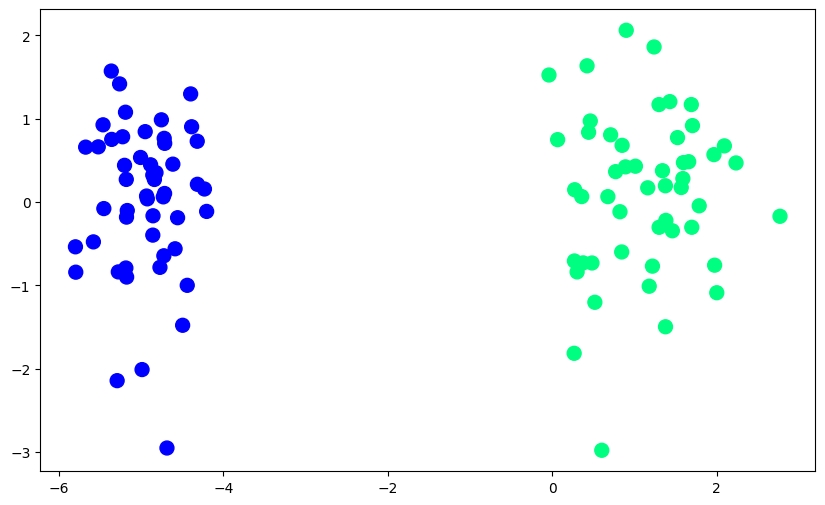

In [28]:
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="winter", s=100)

In [29]:
X.shape

(100, 2)

In [30]:
# def step(z):
#     return 1 if z > 0 else 0

In [31]:
def perceptron(X: np.ndarray, y: np.ndarray, epochs: int = 1000):

    X = np.insert(X, 0, 1, axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1

    for i in range(epochs):
        j = np.random.randint(0, X.shape[0])
        y_hat = 1 if (np.dot(X[j], weights)) > 0 else 0

        weights = weights + lr * (y[j] - y_hat) * X[j]

    return weights[0], weights[1:]

In [32]:
intercept_, coef_ = perceptron(X, y, epochs=100)

print(intercept_, "\n", coef_)

1.2000000000000002 
 [1.08682872 0.52024363]


In [33]:
# Convert Ax+By+c=0 to y=mx+b
# m = -A/B
# c = -C/B

m = -(coef_[0] / coef_[1])
b = -(intercept_ / coef_[1])

In [34]:
# Own logistic regression
x_input = np.linspace(-3, 3, 100)
y_input = m * x_input + b

In [35]:
from sklearn.linear_model import LogisticRegression

lor = LogisticRegression()
lor.fit(X, y)

LogisticRegression()

In [36]:
m = -(lor.coef_[0][0] / lor.coef_[0][1])
b = -(lor.intercept_ / lor.coef_[0][1])

In [37]:
x_input1 = np.linspace(-3, 3, 100)
y_input1 = m * x_input + b

(-3.0, 2.0)

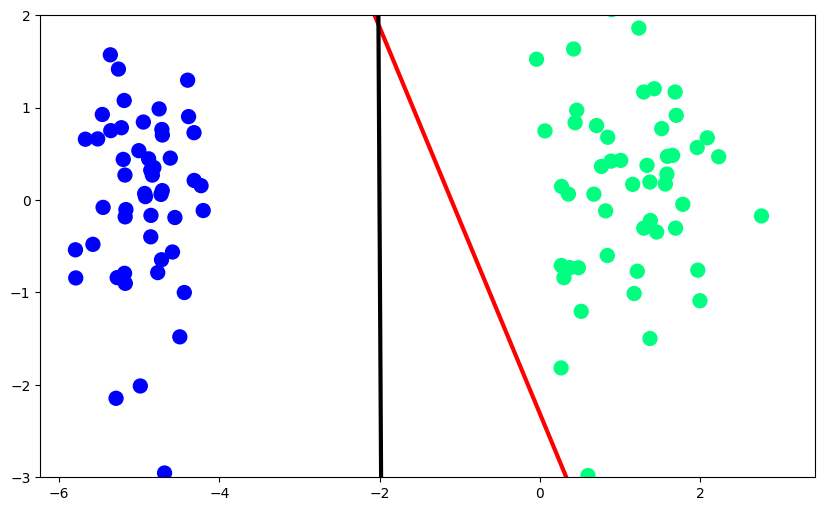

In [38]:
plt.figure(figsize=(10, 6))
plt.plot(x_input, y_input, color="red", linewidth=3)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="winter", s=100)
plt.plot(x_input1, y_input1, color="black", linewidth=3)
plt.ylim(-3, 2)